# Ring Energy Spacing Calculations

## 1. Importing / Installing Packages

In [1]:
import os, glob
from pathlib import Path

import pandas as pd
pd.set_option('display.max_columns', None)

from src.utils import (DatabricksConfig, get_logger, compute_rsv_cat, reorder_columns, 
                       drop_duplicates_keep_max_last_prod, read_csv_with_mapper, 
                       standardize_column_names, add_producing_months, 
                       calculate_cumulative_volumes_by_period, add_bench_columns_to_spacing)

from src.well_data import (WellDataLoader, GeoSurveyProcessor, WellSpacingCalculator, 
                           DirectionalBenchNeighbors, FloatingSectionWPS, BoxSpec, CorridorSpec, AvgSpacingCalculator)

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg' # Configuring inline backend to use SVG format for figures

## 2. Initializing Logger

In [2]:
logger = get_logger(name="spacing_ring_energy", log_to_console=False, level="INFO", propagate=True)

## 3. Importing Well Header and Directional Survey

### 3.1 Initializing Database Configuration 

In [3]:
cfg = DatabricksConfig(
server_hostname="adb-3250236208859616.16.azuredatabricks.net",
http_path="/sql/1.0/warehouses/0cf5fe590cb7b313",
token=os.environ["databricks_token"],
catalog="bronze",
schema="enverus",
)

loader = WellDataLoader(db_cfg=cfg,
                        logger=logger, directional_source="enverus")

### 3.2 Importing Header

In [4]:
def load_uwi_files(folder_path: str) -> pd.DataFrame:
    """
    Reads all .UWI files in the given folder into a single DataFrame.
    
    Parameters
    ----------
    folder_path : str
        Path to the folder containing .UWI files.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['UWI', 'county'].
    """
    all_rows = []

    # Find all .UWI files in the folder
    uwi_paths = glob.glob(os.path.join(folder_path, "*.UWI"))

    for path in uwi_paths:
        county = Path(path).stem  # Extract filename without extension
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            uwis = [line.strip() for line in f if line.strip()]

        print(f"{county}: {len(uwis)} rows")

        for uwi in uwis:
            all_rows.append({"uwi": uwi, "county": county})

    df = pd.DataFrame(all_rows, columns=["uwi", "county"])
    return df

In [5]:
df_uwi_raw = load_uwi_files(folder_path=r"C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\03. Ring Energy\01. Well Header\v1\Raw Well List")

Andrews County: 875 rows
Crane and Ector County: 654 rows
Winkler County: 346 rows
Yoakum County: 823 rows


In [6]:
uwis_14 = df_uwi_raw["uwi"].astype(str).dropna().unique().tolist()

In [7]:
header_query = """
    SELECT
        API_UWI_14_Unformatted AS uwi,
        API_UWI_12_Unformatted AS uwi12,
        LeaseName AS lease_name,
        WellName AS well_name,
        ENVOperator AS operator,
        ENVInterval AS bench,
        PermitApprovedDate AS permit_date,
        SpudDate as spud_date,
        CompletionDate AS comp_date,
        FirstProdDate AS first_prod_date,
        LastProducingMonth as last_prod_date,
        Trajectory AS hole_direction,
        ENVWellStatus as well_status,
        LateralLength_FT AS lateral_length_ft,
        Latitude AS surface_lat,
        Longitude AS surface_lon,
        FluidIntensity_BBLPerFT AS fluid_intensity_bbl_per_ft,
        ProppantIntensity_LBSPerFT AS proppant_intensity_lbs_per_ft
    FROM bronze.enverus.wells
    WHERE 
        DeletedDate IS NULL
            AND
        Trajectory = 'HORIZONTAL'
            AND
        API_UWI_14_Unformatted IN :uwis_14
"""

df_header_raw = loader.get_header_data(header_query=header_query,header_params={"uwis_14": uwis_14})

[WARN] Parameter '_user_agent_entry' is deprecated; use 'user_agent_entry' instead. This parameter will be removed in the upcoming releases.
[WARN] Parameter '_user_agent_entry' is deprecated; use 'user_agent_entry' instead. This parameter will be removed in the upcoming releases.


### 3.3 Computing BG Reserve Category

In [8]:
enverus_map = {
     "status": "well_status",
     "last_prod": "last_prod_date",
     "first_prod": "first_prod_date",
     "spud": "spud_date",
     "comp": "completion_date",
     "permit_date": "permit_date",
}

df_header_rsv = df_header_raw.copy()

df_header_rsv["rsv_cat"] = compute_rsv_cat(df=df_header_raw, col_map=enverus_map, source_type="enverus", utc=True)

In [9]:
df_header_raw.shape, df_header_rsv.shape

((2464, 18), (2464, 19))

In [13]:
# Remove duplicates, keeping the one with the max last production date
df_header_rsv = drop_duplicates_keep_max_last_prod(df_header_rsv).copy()

### 3.4 Filtering Header to include 01PDP, 02PA, 02PDNP and 03PUD Rsv Categories

In [14]:
df_header_rsv_filter = df_header_rsv[df_header_rsv["rsv_cat"].isin(["01PDP", "02PDNP", "02PA", "03PUD"])].reset_index(drop=True).copy()

### 3.5 Importing Directional Data

In [16]:
uwis_12_list = df_header_rsv_filter['uwi12'].astype(str).dropna().unique().tolist()

In [17]:
directional_query = """
    SELECT
        API_UWI_12_Unformatted AS uwi12,
        MeasuredDepth_FT AS md,
        TVD_FT AS tvd,
        Inclination_DEG AS inclination,
        Azimuth_DEG AS azimuth,
        Latitude AS latitude,
        Longitude AS longitude,
        E_W AS `deviation_E/W`,
        N_S AS `deviation_N/S`
    FROM bronze.enverus.fulldirectionalsurvey
    WHERE 
        API_UWI_12_Unformatted IN :uwis_12
    ORDER BY 
        API_UWI_12_Unformatted, MeasuredDepth_FT;
"""

df_directional_raw = loader.get_directional_data(directional_query=directional_query, 
                                                directional_params={"uwis_12": uwis_12_list})

[WARN] Parameter '_user_agent_entry' is deprecated; use 'user_agent_entry' instead. This parameter will be removed in the upcoming releases.
[WARN] Parameter '_user_agent_entry' is deprecated; use 'user_agent_entry' instead. This parameter will be removed in the upcoming releases.
[WARN] Parameter '_user_agent_entry' is deprecated; use 'user_agent_entry' instead. This parameter will be removed in the upcoming releases.
[WARN] Parameter '_user_agent_entry' is deprecated; use 'user_agent_entry' instead. This parameter will be removed in the upcoming releases.
[WARN] Parameter '_user_agent_entry' is deprecated; use 'user_agent_entry' instead. This parameter will be removed in the upcoming releases.
[WARN] Parameter '_user_agent_entry' is deprecated; use 'user_agent_entry' instead. This parameter will be removed in the upcoming releases.
[WARN] Parameter '_user_agent_entry' is deprecated; use 'user_agent_entry' instead. This parameter will be removed in the upcoming releases.
[WARN] Parame

### 3.6 Merging UWI from header to directional survey dataframe

In [19]:
df_directional_db_merge_uwi = df_directional_raw.merge(df_header_rsv_filter[['uwi','uwi12']].sort_values("uwi").drop_duplicates(subset=['uwi12'], keep='first'), on='uwi12', how='left')

df_directional_db_merge_uwi = reorder_columns(df_directional_db_merge_uwi,columns_to_move=['uwi'],reference_column='uwi12')

## 4. Computing UTM Coordinates

In [20]:
# Initialize GeoSurveyProcessor
geo = GeoSurveyProcessor(logger=logger)

# Compute UTM coordinates
df_utm = geo.compute_utm_coordinates(df=df_directional_db_merge_uwi)

# Filter to lateral section after heel point
df_utm_lateral = geo.filter_after_heel_point(df=df_utm)

# Calculate midpoints for lateral wells
df_midpoints_lateral = geo.get_heel_toe_midpoints_latlon(df=df_utm_lateral)

## 5. Spacing Algorithm

### 5.1 Filtering well header data whose directional surveys are missing

In [22]:
missing_uwi = set(df_header_rsv_filter['uwi12']) - set(df_utm_lateral['uwi12'])
print(f"Number of missing UWI from header dataframe: {len(missing_uwi)}")
# list(missing_uwi)

Number of missing UWI from header dataframe: 22


In [23]:
df_header_filter_for_spacing = df_header_rsv_filter[~df_header_rsv_filter['uwi12'].isin(missing_uwi)].reset_index(drop=True).copy()

In [24]:
df_header_filter_for_spacing

,uwi,uwi12,lease_name,well_name,operator,bench,permit_date,spud_date,comp_date,first_prod_date,last_prod_date,hole_direction,well_status,lateral_length_ft,surface_lat,surface_lon,fluid_intensity_bbl_per_ft,proppant_intensity_lbs_per_ft,rsv_cat
0,42501367160100,425013671601,SLIM HONEYCUTT 608,SLIM HONEYCUTT 608 4XH,RILEY EXPLORATION PERMIAN,TEXAS SHELF ALL,2016-08-30 00:00:00+00:00,2016-10-03 00:00:00+00:00,2017-01-17 00:00:00+00:00,2017-01-01 00:00:00+00:00,2025-11-01 00:00:00+00:00,HORIZONTAL,PRODUCING,4638.0,33.095664,-102.851142,5.391783,NaN,01PDP
1,42003385790000,420033857900,STATE FI,STATE FI 11H,LIME ROCK,CENTRAL BASIN PLATFORM ALL,2000-02-14 00:00:00+00:00,1954-06-05 00:00:00+00:00,2000-04-15 00:00:00+00:00,2000-04-01 00:00:00+00:00,2009-11-01 00:00:00+00:00,HORIZONTAL,P & A,1869.0,32.148114,-102.600488,NaN,NaN,02PA
2,42475389480000,424753894800,KING GEORGE,KING GEORGE 7705WH,CONOCOPHILLIPS,WOODFORD,2025-03-03 00:00:00+00:00,2025-07-17 00:00:00+00:00,NaT,NaT,NaT,HORIZONTAL,DUC,14904.0,31.585179,-103.097311,NaN,NaN,03PUD
3,42103375340000,421033753400,WADDELL TR A,WADDELL TR A 4049H,BLACKBEARD OPERATING,CENTRAL BASIN PLATFORM ALL,2024-11-26 00:00:00+00:00,2024-12-04 00:00:00+00:00,2025-09-15 00:00:00+00:00,2025-09-01 00:00:00+00:00,2025-11-01 00:00:00+00:00,HORIZONTAL,PRODUCING,11413.0,31.537138,-102.638621,4.370760,222.246078,01PDP
4,42475389560000,424753895600,KING GEORGE,KING GEORGE 7707WH,CONOCOPHILLIPS,WOODFORD,2025-03-03 00:00:00+00:00,2025-07-15 00:00:00+00:00,NaT,NaT,NaT,HORIZONTAL,DUC,15035.0,31.585216,-103.097359,NaN,NaN,03PUD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1919,42165324830100,421653248301,WHARTON UNIT,WHARTON UNIT 113,MACH NATURAL RESOURCES LP,CENTRAL BASIN PLATFORM ALL,1982-12-27 00:00:00+00:00,1983-03-04 00:00:00+00:00,NaT,1983-03-01 00:00:00+00:00,NaT,HORIZONTAL,PRODUCING,1021.0,32.576304,-102.676223,NaN,NaN,02PDNP
1920,42003034550100,420030345501,SHAFTER LAKE /SAN ANDRES/ UNIT,SHAFTER LAKE /SAN ANDRES/ UNIT 96W,HILCORP,CENTRAL BASIN PLATFORM ALL,2004-05-04 00:00:00+00:00,NaT,2010-10-18 00:00:00+00:00,1968-02-01 00:00:00+00:00,NaT,HORIZONTAL,TA,2312.0,32.345908,-102.606148,NaN,NaN,02PA
1921,42003434610100,420034346101,UNIVERSITY 24A,UNIVERSITY 24A 3,CRESCENT ENERGY COMPANY,CENTRAL BASIN PLATFORM ALL,2011-09-26 00:00:00+00:00,2011-10-01 00:00:00+00:00,NaT,2011-10-01 00:00:00+00:00,NaT,HORIZONTAL,P & A,1763.0,32.163786,-102.649159,NaN,NaN,02PA
1922,42003416510100,420034165101,UNIVERSITY BLOCK 9,UNIVERSITY BLOCK 9 8A,EXXON,CENTRAL BASIN PLATFORM ALL,2010-04-29 00:00:00+00:00,2010-06-16 00:00:00+00:00,2015-09-03 00:00:00+00:00,2010-09-01 00:00:00+00:00,NaT,HORIZONTAL,TA,2560.0,32.211560,-102.568983,NaN,NaN,02PA


In [44]:
# of UWIs in header filter not present in UTM lateral data
list(set(df_header_filter_for_spacing['uwi12']) - set(df_utm_lateral[df_utm_lateral["uwi12"].isin(df_header_filter_for_spacing["uwi12"].unique())]["uwi12"]))

[]

### 5.2 Calculate Spacing

In [26]:
# Create WellSpacingCalculator instance
spacing_stats_ik = WellSpacingCalculator(trajectories=df_utm_lateral[df_utm_lateral["uwi12"].isin(df_header_filter_for_spacing["uwi12"].unique())])

In [27]:
# Calculate spacing statistics with specified parameters and save the results in parquet files
calculate_spacing = False

if calculate_spacing:
    spacing_stats_ik._calculate_spacing_statistics(
        batch_size=300_000,
        max_distance_miles=3.0,
        save_batches_dir=r"C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\03. Ring Energy\04. Spacing Results\v2",
        max_crossline_ft=10_560
    )

### 5.3 Read Calculated and Saved Spacing Results from Parquet Files

In [28]:
df_spacing_ik = spacing_stats_ik._load_saved_batches(
    batch_folder=r"C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\03. Ring Energy\04. Spacing Results\v2"
)

🔍 Found 1 batch files. Loading and combining...
✅ Loaded 118,932 rows from all batches.


### 5.4 Filtering rows where for overlapping wells only

In [29]:
# Filter out rejected spacing calculations
df_spacing_ik_filt = df_spacing_ik[df_spacing_ik["reject_reason"]==""].reset_index(drop=True).copy()

### 5.5 Merging bench from header data with spacing ik filtered dataframe

In [30]:
df_spacing_ik_filt = add_bench_columns_to_spacing(df_spacing=df_spacing_ik_filt, df_header=df_header_filter_for_spacing, reorder_columns_func=reorder_columns).copy()

In [31]:
df_spacing_ik_filt

,well_i,well_k,bench_i,bench_k,horizontal_dist,horizontal_dist_median,vertical_dist,3D_dist,direction_to_k_from_i_axis,overlap_pct_i,overlap_pct_k,overlap_len_common_ft,LL_i,LL_k,drill_direction_i,drill_direction_k,n_samples,dy_p5,angle_deg,pair_alignment,min_distance_ft,mean_windowed_ft,reject_reason,direction_axis,direction_axis_confidence,direction_axis_distribution,axis_forced,proj_coverage_i_pct,contact_threshold_ft,contact_len_i_ft,contact_pct_i,contact_len_i_interior_ft,contact_pct_i_interior,contact_len_i_ft_T300,contact_pct_i_T300,contact_len_i_interior_ft_T300,contact_pct_i_interior_T300,horizontal_crossline_mean_ft,hz_effective,hz_basis,3D_dist_effective
0,30025421210000,30025426220000,NM SHELF ALL,NM SHELF ALL,1251.236565,1251.685862,26.050000,1251.507708,W,0.998530,0.995422,4315.693016,4322.045883,4335.543217,NS,NS,44.0,1191.243322,2.092210,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1251.236565,1251.236565,crossline_mean,1251.507708
1,30025421210000,30025428730000,NM SHELF ALL,NM SHELF ALL,1564.653000,1563.432070,46.050000,1565.330513,E,0.964435,0.999940,4168.331669,4322.045883,4168.582388,NS,NS,42.0,1546.281480,0.428165,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1564.653000,1564.653000,crossline_mean,1565.330513
2,30025421210000,42501367020000,NM SHELF ALL,TEXAS SHELF ALL,5824.677955,5825.117802,48.615000,5824.880831,E,0.941324,0.516891,4068.445617,4322.045883,7871.000453,NS,NS,41.0,5722.085437,3.026274,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5824.677955,5824.677955,crossline_mean,5824.880831
3,30025421210000,42501368050000,NM SHELF ALL,TEXAS SHELF ALL,7079.319157,7079.319157,21.201063,7079.350903,E,0.001743,0.001495,7.535048,4322.045883,5041.176120,NS,NS,2.0,7079.152301,1.031264,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7079.319157,7079.319157,crossline_mean,7079.350903
4,30025421210000,42501368060000,NM SHELF ALL,TEXAS SHELF ALL,8180.990919,8168.590853,16.709776,8181.007984,E,0.943229,0.886915,4076.677656,4322.045883,4596.468450,NS,NS,41.0,8155.960081,0.815549,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8180.990919,8180.990919,crossline_mean,8181.007984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49331,42501376130000,42501374210000,TEXAS SHELF ALL,TEXAS SHELF ALL,6025.754025,6018.875256,97.125000,6026.536720,W,0.190149,0.208872,984.940444,5179.836340,4715.511765,NS,NS,10.0,6007.067001,0.677657,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6025.754025,6025.754025,crossline_mean,6026.536720
49332,42501376130000,42501374220000,TEXAS SHELF ALL,TEXAS SHELF ALL,7543.484745,7536.624280,87.135000,7543.987978,W,0.187910,0.214156,973.342600,5179.836340,4545.014430,NS,NS,10.0,7531.565956,0.263237,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7543.484745,7543.484745,crossline_mean,7543.987978
49333,42501376130000,42501374980000,TEXAS SHELF ALL,TEXAS SHELF ALL,2639.331840,2640.961978,47.995000,2639.768187,W,0.994276,0.785027,5150.185942,5179.836340,6560.524646,NS,NS,52.0,2601.465157,0.413000,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2639.331840,2639.331840,crossline_mean,2639.768187
49334,42501376130000,42501374990000,TEXAS SHELF ALL,TEXAS SHELF ALL,1966.921834,1970.855477,41.015000,1967.349418,W,0.994432,0.791239,5150.993532,5179.836340,6510.033510,NS,NS,52.0,1919.862032,0.695167,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1966.921834,1966.921834,crossline_mean,1967.349418


## 6. One-Lines

### 6.1 Running oneline

In [32]:
nb = DirectionalBenchNeighbors()

one_line_summary = nb.summarize(
    spacing_df=df_spacing_ik_filt, 
    header_df=df_header_filter_for_spacing,
    cutoff_ft=1_800.0,
    vertical_cutoff_ft=200.0,         # global default if per-well vertical is NaN/missing
    axis_mode="any",
    overlap_pct_k_min=0.40,           # global default if per-well overlap is NaN/missing
)

In [33]:
one_line_summary

,well_i,bound_category,uwi_same_1,hz_ft_to_same_1,vt_ft_to_same_1,3d_ft_to_same_1,uwi_same_2,hz_ft_to_same_2,vt_ft_to_same_2,3d_ft_to_same_2,uwi_near_1,hz_ft_to_near_1,vt_ft_to_near_1,3d_ft_to_near_1,uwi_near_2,hz_ft_to_near_2,vt_ft_to_near_2,3d_ft_to_near_2,override_applied,eff_cutoff_ft,eff_vertical_cutoff_ft,eff_overlap_pct_k_min
0,30025421210000,Mostly Bounded,30025426220000,1251.236565,26.050000,1251.507708,30025428730000,1564.653000,46.050,1565.330513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
1,30025426220000,Partially Bounded,30025421210000,1251.252318,26.050000,1251.523457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
2,30025428730000,Partially Bounded,30025421210000,1564.664825,46.050000,1565.342332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
3,30025438900000,Unbounded,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
4,30025449160000,Mostly Bounded,30025463300000,1095.636467,18.165556,1095.787048,30025494190000,1412.901990,62.930,1414.302733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1877,42501376080000,Mostly Bounded,42501371140000,576.548070,51.360000,578.831173,42501376070000,730.096951,9.700,730.161385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
1878,42501376090000,Partially Bounded,42501366970000,681.055305,68.695000,684.511016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
1879,42501376100000,Mostly Bounded,42501376080000,817.345764,7.785000,817.382839,42501366270000,851.153758,41.965,852.187644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
1880,42501376110000,Mostly Bounded,42501373050000,694.598005,46.185000,696.131771,42501373040000,810.590194,61.975,812.955942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4


## 7. WPS

### 7.1 Calculating WPS

In [34]:
box = BoxSpec(half_width_ft=5280.0 / 2,  # 2640 ft (1 mile wide)
              half_height_ft=5280.0 / 2)  # 5280 ft (2 miles tall)

corr = CorridorSpec(half_width_ft=2640.0, extra_along_ft=0)

wells_df = FloatingSectionWPS.ds_to_lateral_endpoints(df_utm_lateral[df_utm_lateral["uwi12"].isin(df_header_filter_for_spacing["uwi12"].unique())])

wps = FloatingSectionWPS(
    wells_df,
    # box=BoxSpec(2640, 2640),
    box=box,
    min_inside_ft=1000.0,
    exclude_self=False,
    corridor=corr,
)

df_wps_summary = wps.summarize_per_well()

In [35]:
df_wps_summary

,well_i,wps_cardinal,wps_iframe,wps_corridor,anisotropy_ratio,anisotropy_delta,azimuth_deg,mid_x,mid_y
0,30025421210000,3,3,3,1.000000,0.0,359.745977,2.231648e+06,1.202811e+07
1,30025426220000,2,2,2,1.000000,0.0,357.667939,2.230388e+06,1.202811e+07
2,30025428730000,3,3,2,1.000000,0.0,359.794320,2.233223e+06,1.202818e+07
3,30025438900000,1,1,1,1.000000,0.0,178.773012,2.213129e+06,1.208053e+07
4,30025449160000,3,3,3,1.000000,0.0,356.806625,2.227864e+06,1.208077e+07
...,...,...,...,...,...,...,...,...,...
1908,42501376080000,10,10,10,1.000000,0.0,359.994738,2.280058e+06,1.202563e+07
1909,42501376090000,6,5,5,0.833333,-1.0,358.958270,2.282248e+06,1.201652e+07
1910,42501376100000,5,5,5,1.000000,0.0,358.657875,2.279243e+06,1.202294e+07
1911,42501376110000,6,6,6,1.000000,0.0,178.856910,2.277994e+06,1.200168e+07


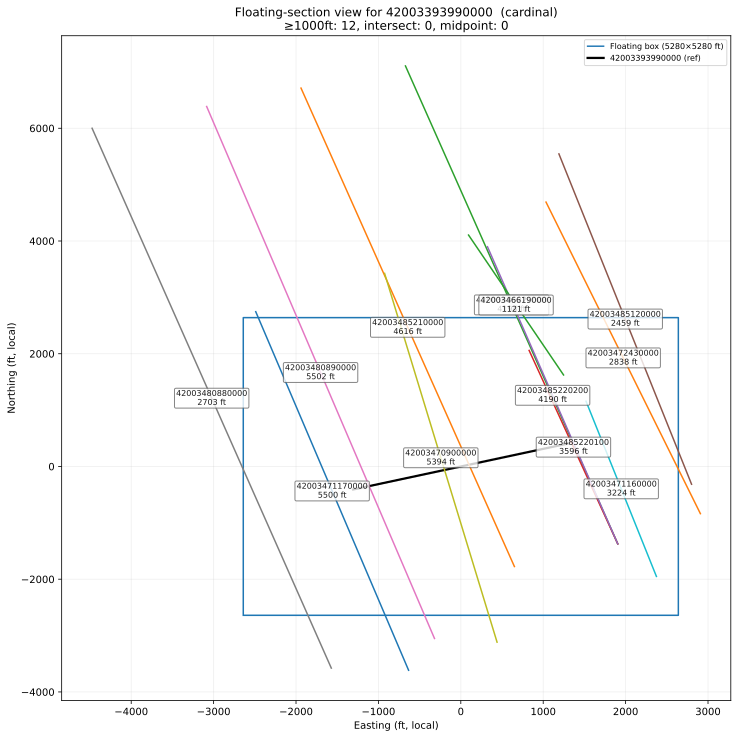

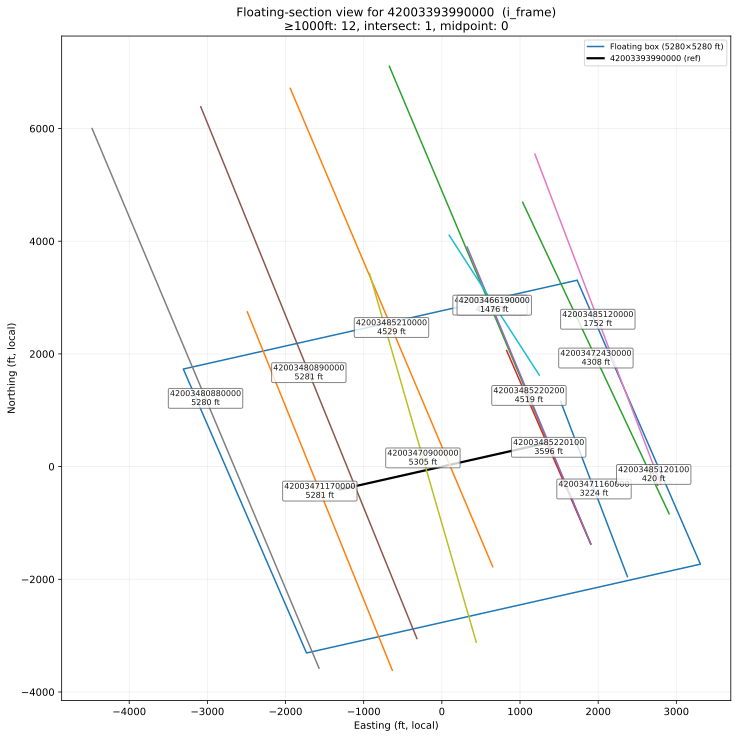

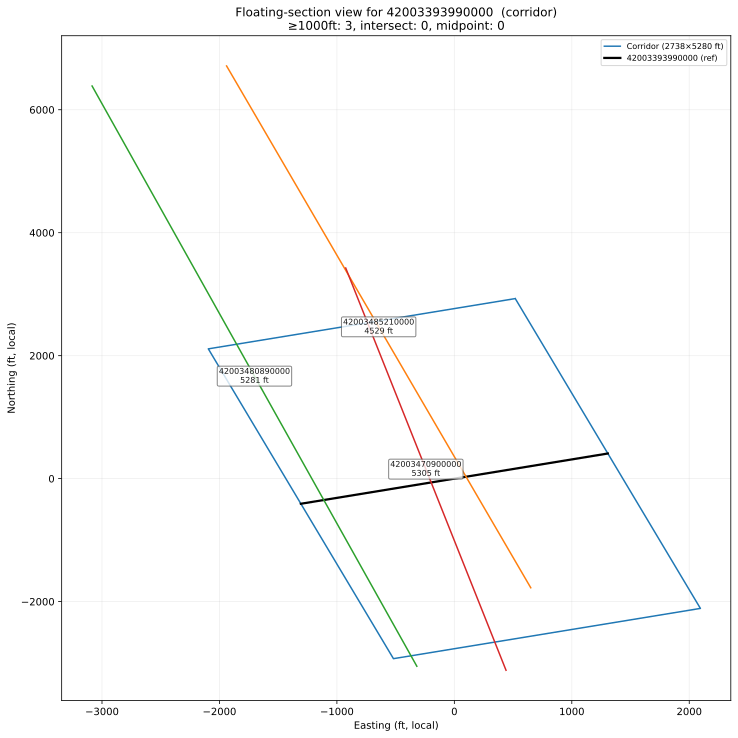

In [61]:
uwi = "42003393990000"

# Cardinal floating-section view
fig = wps.visualize(uwi, orientation="cardinal", figsize=(12,12))

# I-frame view (box aligned to reference lateral)
fig_if = wps.visualize(uwi, orientation="i_frame", min_len_ft=1000, figsize=(12,12))

fig_corr = wps.visualize(uwi, orientation="corridor", min_len_ft=1000, figsize=(12,12))

## 8. Average Well Spacing

### 8.1 Calculating Average Spacing

In [36]:
avg_spacing = AvgSpacingCalculator()

df_avg_spacing = avg_spacing.summarize(spacing_df=df_spacing_ik_filt,
                      cutoff_ft=1_800.0,
                      vertical_cutoff_ft=200.0,
                      overlap_pct_k_min=0.40,
                      trajectories=df_utm_lateral[df_utm_lateral["uwi12"].isin(df_header_filter_for_spacing["uwi12"].unique())])

C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\02.Python\well-spacing-analyzer\src\well_data\well_spacing_stats.py:5399: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_order_members_one_group)


In [37]:
df_avg_spacing

,well_i,group_size,neighbors_in_group,survivor_rows_i_to_k,chain_sort_mode,chain_axis_dx,chain_axis_dy,chain_edges_used,chain_edges_missing,hz_mean_chain_ft,vt_mean_chain_ft,p50_hz_chain_edge_ft,p25_hz_chain_edge_ft,p75_hz_chain_edge_ft,min_hz_chain_edge_ft,max_hz_chain_edge_ft,avg_hz_spacing_ft,avg_vt_spacing_ft,neighborhood_mode_used
0,30025421210000,3,2,2,pca,0.999743,0.022657,2,0,1407.944783,36.050000,1407.944783,1329.590674,1486.298892,1251.236565,1564.653000,1407.944783,36.050000,chain
1,30025426220000,2,1,1,pca,0.997881,0.065059,1,0,1251.236565,26.050000,1251.236565,1251.236565,1251.236565,1251.236565,1251.236565,1251.236565,26.050000,chain
2,30025428730000,2,1,1,pca,0.999961,-0.008821,1,0,1564.653000,46.050000,1564.653000,1564.653000,1564.653000,1564.653000,1564.653000,1564.653000,46.050000,chain
3,30025438900000,1,0,0,pca,1.000000,0.000000,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,chain
4,30025449160000,3,2,2,pca,0.848073,-0.529880,2,0,1254.269229,40.547778,1254.269229,1174.952848,1333.585609,1095.636467,1412.901990,1254.269229,40.547778,chain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1877,42501376080000,7,6,6,pca,-0.036763,0.999324,6,0,1368.831181,27.810000,1090.007859,856.428451,1360.565872,730.096951,3073.553894,1368.831181,27.810000,chain
1878,42501376090000,3,2,2,pca,0.920067,0.391762,2,0,667.561859,81.000000,667.561859,660.818756,674.304961,654.075654,681.048063,667.561859,81.000000,chain
1879,42501376100000,4,3,3,pca,0.542245,0.840220,3,0,799.470133,19.816667,817.345764,773.721358,834.156723,730.096951,850.967682,799.470133,19.816667,chain
1880,42501376110000,4,3,3,pca,0.942235,-0.334952,3,0,735.705618,51.105000,701.928655,698.263330,756.259425,694.598005,810.590194,735.705618,51.105000,chain


## 9. Production

### 9.1 Reading Production Data from file

In [70]:
df_prod_raw = read_csv_with_mapper(
    path=r"C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\03. Ring Energy\03. Production\production_data_02_04_26.csv",
    col_map={
        "API_UWI_14_Unformatted":"uwi", "API_UWI_Unformatted":"uwi_10", "ProducingMonth":"prod_date",
        "Prod_OilBBL": "monthly_oil_bbl", "GasProd_MCF": "monthly_gas_mcf",
        "WaterProd_BBL": "monthly_water_bbl"
        },
    parse_dates=["ProducingMonth"],
    dtype_map={"uwi": "string", "uwi_10": "string"}
)

C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\02.Python\well-spacing-analyzer\src\utils\utils.py:140: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, **read_kwargs)


In [71]:
df_prod_raw

,API_UWI,uwi_10,API_UWI_14,uwi,CDFlaredGas_MCFPerDAY,CDGas_MCFPerDAY,CDInjectionGas_MCFPerDAY,CDInjectionOther_BBLPerDAY,CDInjectionSolvent_BBLPerDAY,CDInjectionSteam_BBLPerDAY,CDInjectionWater_BBLPerDAY,CDLiquids_BBLPerDAY,CDProd_BOEPerDAY,CDProd_MCFEPerDAY,CDRepGas_MCFPerDAY,CDWater_BBLPerDAY,CompletionID,Country,County,CumFlaredGas_MCF,CumGas_MCF,CumLiquids_BBL,CumProd_BOE,CumProd_MCFE,CumRepGas_MCF,CumWater_BBL,DeletedDate,ENVBasin,ENVInterval,ENVPlay,ENVProdID,ENVRegion,FlaredGasProd_MCF,monthly_gas_mcf,InjectionGas_MCF,InjectionOther_BBL,InjectionSolvent_BBL,InjectionSteam_BBL,InjectionWater_BBL,LiquidsProd_BBL,PDFlaredGas_MCFPerDAY,PDGas_MCFPerDAY,PDLiquids_BBLPerDAY,PDProd_BOEPerDAY,PDProd_MCFEPerDAY,PDRepGas_MCFPerDAY,PDWater_BBLPerDAY,Prod_BOE,Prod_CondensateBBL,Prod_MCFE,monthly_oil_bbl,ProducingDays,prod_date,ProducingOperator,ProductionID,ProductionReportedMethod,RepGasProd_MCF,StateProvince,TotalCompletionMonths,TotalProdMonths,UpdatedDate,monthly_water_bbl,WellID,LastLoadDateTime
0,30-025-42121,3002542121,30-025-42121-00-00,30025421210000,0.0,86.46,NaN,NaN,NaN,NaN,NaN,93.96,108.38,650.25,0.0,463.54,840301000707185,US,LEA,0.0,75732.0,77269.0,89891.00,539346.0,0.0,423707.0,NaN,PERMIAN OTHER,NM SHELF ALL,NM SHELF,1,PERMIAN,0.0,2421.0,NaN,NaN,NaN,NaN,NaN,2631.0,0.0,86.46,93.96,108.38,650.25,0.0,463.54,3034.50,0.0,18207.0,2631.0,28.0,2017-02-01 00:00:00+00:00,"STEWARD ENERGY II, LLC",8403000011050531024,REPORTED,0.0,NM,24,24,2023-01-13T21:56:42.000Z,12979.0,840300001105053,2025-10-15T22:50:43.330Z
1,30-025-42622,3002542622,30-025-42622-00-00,30025426220000,0.0,141.13,NaN,NaN,NaN,NaN,NaN,52.63,76.16,456.93,0.0,342.03,840301003244287,US,LEA,0.0,121058.0,95360.0,115536.34,693218.0,0.0,594075.0,NaN,PERMIAN OTHER,NM SHELF ALL,NM SHELF,1,PERMIAN,0.0,4234.0,NaN,NaN,NaN,NaN,NaN,1579.0,0.0,141.13,52.63,76.16,456.93,0.0,342.03,2284.67,0.0,13708.0,1579.0,30.0,2018-09-01 00:00:00+00:00,"STEWARD ENERGY II, LLC",8403000011054581038,REPORTED,0.0,NM,38,38,2023-01-13T21:56:42.000Z,10261.0,840300001105458,2025-10-15T22:50:43.330Z
2,30-025-42873,3002542873,30-025-42873-00-00,30025428730000,0.0,110.47,NaN,NaN,NaN,NaN,NaN,41.13,59.54,357.27,0.0,216.93,840301000708541,US,LEA,0.0,142728.0,117360.0,141148.00,846888.0,0.0,580987.0,NaN,PERMIAN OTHER,NM SHELF ALL,NM SHELF,1,PERMIAN,0.0,3314.0,NaN,NaN,NaN,NaN,NaN,1234.0,0.0,110.47,41.13,59.54,357.27,0.0,216.93,1786.33,0.0,10718.0,1234.0,30.0,2018-09-01 00:00:00+00:00,"STEWARD ENERGY II, LLC",8403000011057001034,REPORTED,0.0,NM,34,34,2023-01-13T21:56:42.000Z,6508.0,840300001105700,2025-10-15T22:50:43.330Z
3,30-025-42121,3002542121,30-025-42121-00-00,30025421210000,0.0,44.37,NaN,NaN,NaN,NaN,NaN,36.03,43.43,260.57,0.0,248.23,840301000707185,US,LEA,0.0,82662.0,81239.0,95016.00,570096.0,0.0,448496.0,NaN,PERMIAN OTHER,NM SHELF ALL,NM SHELF,1,PERMIAN,0.0,1331.0,NaN,NaN,NaN,NaN,NaN,1081.0,0.0,44.37,36.03,43.43,260.57,0.0,248.23,1302.83,0.0,7817.0,1081.0,30.0,2017-06-01 00:00:00+00:00,"STEWARD ENERGY II, LLC",8403000011050531028,REPORTED,0.0,NM,28,28,2023-01-13T21:56:42.000Z,7447.0,840300001105053,2025-10-15T22:50:43.330Z
4,30-025-42121,3002542121,30-025-42121-00-00,30025421210000,0.0,59.94,NaN,NaN,NaN,NaN,NaN,38.52,48.51,291.03,0.0,276.23,840301000707185,US,LEA,0.0,152686.0,108502.0,133949.67,803698.0,0.0,615378.0,NaN,PERMIAN OTHER,NM SHELF ALL,NM SHELF,1,PERMIAN,0.0,1858.0,NaN,NaN,NaN,NaN,NaN,1194.0,0.0,59.94,38.52,48.51,291.03,0.0,276.23,1503.67,0.0,9022.0,1194.0,31.0,2018-12-01 00:00:00+00:00,"STEWARD ENERGY II, LLC",8403000011050531046,REPORTED,0.0,NM,46,46,2023-01-13T21:56:42.000Z,8563.0,840300001105053,2025-10-15T22:50:43.330Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140521,30-025-51113,3002551113,30-025-51113-00-00,30025511130000,0.0,54.83,NaN,NaN,NaN,NaN,NaN,48.77,57.91,347.43,0.

### 9.2 Standardizing Column Names

In [72]:
df_prod_standardize = standardize_column_names(df_prod_raw)

### 9.3 Calculating Producing Months

In [73]:
df_prod_standardize = add_producing_months(df=df_prod_standardize, date_col="prod_date", uwi_col="uwi", out_col="producing_months_calc")

In [74]:
# Reorder columns to place 'producing_months_calc' after 'prod_date'
df_prod_standardize = reorder_columns(df=df_prod_standardize, columns_to_move=["monthly_oil_bbl", "monthly_gas_mcf","monthly_water_bbl", "prod_date", "producing_months_calc"], reference_column="uwi")

### 9.4 Merging Lateral Length

In [75]:
# Merge lateral length into production dataframe
df_prod_standardize = df_prod_standardize.merge(df_header_filter_for_spacing[['uwi', 'lateral_length_ft']], on='uwi', how='left')

### 9.5 Calculating Cumulative Volumes by Period (180 & 365 days)

In [76]:
df_uwi_180_365d_cum = calculate_cumulative_volumes_by_period(df_prod_standardize, oil_col='monthly_oil_bbl',gas_col='monthly_gas_mcf',water_col='monthly_water_bbl', lateral_length_col='lateral_length_ft')

In [77]:
df_uwi_180_365d_cum

,uwi,lateral_length_ft,cum_oil_180d,cum_gas_180d,cum_water_180d,cum_oil_365d,cum_gas_365d,cum_water_365d,cum_oil_180d_per_ft,cum_gas_180d_per_ft,cum_water_180d_per_ft,cum_oil_365d_per_ft,cum_gas_365d_per_ft,cum_water_365d_per_ft
0,30025421210000,4323.0,34398.0,30948.0,151060.00,52141.0,49133.0,263464.00,7.956974,7.158917,34.943326,12.061300,11.365487,60.944714
1,30025426220000,4336.0,21307.0,13607.0,137641.00,39595.0,26548.0,235115.00,4.913976,3.138146,31.743773,9.131688,6.122694,54.223939
2,30025428730000,4170.0,25703.0,11485.0,184788.00,56772.0,30658.0,303630.00,6.163789,2.754197,44.313669,13.614388,7.352038,72.812950
3,30025438900000,4564.0,14586.0,2511.0,220211.00,25431.0,7364.0,365955.00,3.195881,0.550175,48.249562,5.572086,1.613497,80.182954
4,30025449160000,5211.0,35497.0,4561.0,151765.00,75114.0,11063.0,319397.00,6.811936,0.875264,29.123969,14.414508,2.123009,61.292842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1783,42501376010000,2967.0,34147.0,49776.0,0.00,43729.0,64740.0,0.00,11.508932,16.776542,0.000000,14.738456,21.820020,0.000000
1784,42501376030000,6353.0,68725.0,84619.0,175663.96,106636.0,165759.0,320968.88,10.817724,13.319534,27.650552,16.785141,26.091453,50.522411
1785,42501376040000,7958.0,15530.0,10099.0,0.00,15530.0,10099.0,0.00,1.951495,1.269037,0.000000,1.951495,1.269037,0.000000
1786,42501376110000,5167.0,33060.0,48307.0,0.00,39023.0,57618.0,0.00,6.398297,9.349139,0.000000,7.552351,11.151152,0.000000


## 10. Final Merge

### 10.1 Merging WPS summary dataframe with Cumulative Volumes dataframe

In [78]:
df_cum_merge_wps = df_uwi_180_365d_cum.merge(df_wps_summary[['well_i', 'wps_cardinal', 'wps_iframe', 'wps_corridor']].rename(columns={"well_i": "uwi"}), on='uwi', how='left').drop(columns=["lateral_length_ft"]).reset_index(drop=True)

In [79]:
df_cum_merge_wps

,uwi,cum_oil_180d,cum_gas_180d,cum_water_180d,cum_oil_365d,cum_gas_365d,cum_water_365d,cum_oil_180d_per_ft,cum_gas_180d_per_ft,cum_water_180d_per_ft,cum_oil_365d_per_ft,cum_gas_365d_per_ft,cum_water_365d_per_ft,wps_cardinal,wps_iframe,wps_corridor
0,30025421210000,34398.0,30948.0,151060.00,52141.0,49133.0,263464.00,7.956974,7.158917,34.943326,12.061300,11.365487,60.944714,3.0,3.0,3.0
1,30025426220000,21307.0,13607.0,137641.00,39595.0,26548.0,235115.00,4.913976,3.138146,31.743773,9.131688,6.122694,54.223939,2.0,2.0,2.0
2,30025428730000,25703.0,11485.0,184788.00,56772.0,30658.0,303630.00,6.163789,2.754197,44.313669,13.614388,7.352038,72.812950,3.0,3.0,2.0
3,30025438900000,14586.0,2511.0,220211.00,25431.0,7364.0,365955.00,3.195881,0.550175,48.249562,5.572086,1.613497,80.182954,1.0,1.0,1.0
4,30025449160000,35497.0,4561.0,151765.00,75114.0,11063.0,319397.00,6.811936,0.875264,29.123969,14.414508,2.123009,61.292842,3.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1783,42501376010000,34147.0,49776.0,0.00,43729.0,64740.0,0.00,11.508932,16.776542,0.000000,14.738456,21.820020,0.000000,5.0,6.0,5.0
1784,42501376030000,68725.0,84619.0,175663.96,106636.0,165759.0,320968.88,10.817724,13.319534,27.650552,16.785141,26.091453,50.522411,8.0,7.0,14.0
1785,42501376040000,15530.0,10099.0,0.00,15530.0,10099.0,0.00,1.951495,1.269037,0.000000,1.951495,1.269037,0.000000,13.0,13.0,15.0
1786,42501376110000,33060.0,48307.0,0.00,39023.0,57618.0,0.00,6.398297,9.349139,0.000000,7.552351,11.151152,0.000000,6.0,6.0,6.0


### 10.2 Merge df_cum_merge_wps dataframe with header

In [80]:
df_header_final_spacing = df_header_filter_for_spacing.merge(df_cum_merge_wps, on='uwi', how='left')

### 10.3 Merge df_utm_lateral dataframe with header to get final header data that will go to Spotfire

In [81]:
df_header_final_spacing = df_header_final_spacing.merge(df_utm_lateral.groupby('uwi')['tvd'].agg('mean').reset_index(), on='uwi', how='left')

In [82]:
df_header_final_spacing

,uwi,uwi12,lease_name,well_name,operator,bench,permit_date,spud_date,comp_date,first_prod_date,last_prod_date,hole_direction,well_status,lateral_length_ft,surface_lat,surface_lon,fluid_intensity_bbl_per_ft,proppant_intensity_lbs_per_ft,rsv_cat,cum_oil_180d,cum_gas_180d,cum_water_180d,cum_oil_365d,cum_gas_365d,cum_water_365d,cum_oil_180d_per_ft,cum_gas_180d_per_ft,cum_water_180d_per_ft,cum_oil_365d_per_ft,cum_gas_365d_per_ft,cum_water_365d_per_ft,wps_cardinal,wps_iframe,wps_corridor,tvd
0,42501367160100,425013671601,SLIM HONEYCUTT 608,SLIM HONEYCUTT 608 4XH,RILEY EXPLORATION PERMIAN,TEXAS SHELF ALL,2016-08-30 00:00:00+00:00,2016-10-03 00:00:00+00:00,2017-01-17 00:00:00+00:00,2017-01-01 00:00:00+00:00,2025-11-01 00:00:00+00:00,HORIZONTAL,PRODUCING,4638.0,33.095664,-102.851142,5.391783,NaN,01PDP,2119.00,194.00,86667.20,2971.00,340.00,121500.38,0.456878,0.041828,18.686330,0.640578,0.073307,26.196718,1.0,1.0,1.0,5311.688113
1,42003385790000,420033857900,STATE FI,STATE FI 11H,LIME ROCK,CENTRAL BASIN PLATFORM ALL,2000-02-14 00:00:00+00:00,1954-06-05 00:00:00+00:00,2000-04-15 00:00:00+00:00,2000-04-01 00:00:00+00:00,2009-11-01 00:00:00+00:00,HORIZONTAL,P & A,1869.0,32.148114,-102.600488,NaN,NaN,02PA,1975.00,0.00,0.00,5955.00,9028.00,0.00,1.056715,0.000000,0.000000,3.186196,4.830391,0.000000,8.0,8.0,4.0,10683.094462
2,42475389480000,424753894800,KING GEORGE,KING GEORGE 7705WH,CONOCOPHILLIPS,WOODFORD,2025-03-03 00:00:00+00:00,2025-07-17 00:00:00+00:00,NaT,NaT,NaT,HORIZONTAL,DUC,14904.0,31.585179,-103.097311,NaN,NaN,03PUD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14950.625125
3,42103375340000,421033753400,WADDELL TR A,WADDELL TR A 4049H,BLACKBEARD OPERATING,CENTRAL BASIN PLATFORM ALL,2024-11-26 00:00:00+00:00,2024-12-04 00:00:00+00:00,2025-09-15 00:00:00+00:00,2025-09-01 00:00:00+00:00,2025-11-01 00:00:00+00:00,HORIZONTAL,PRODUCING,11413.0,31.537138,-102.638621,4.370760,222.246078,01PDP,17956.19,8638.53,62359.13,17956.19,8638.53,62359.13,1.573310,0.756903,5.463868,1.573310,0.756903,5.463868,38.0,36.0,44.0,3408.921679
4,42475389560000,424753895600,KING GEORGE,KING GEORGE 7707WH,CONOCOPHILLIPS,WOODFORD,2025-03-03 00:00:00+00:00,2025-07-15 00:00:00+00:00,NaT,NaT,NaT,HORIZONTAL,DUC,15035.0,31.585216,-103.097359,NaN,NaN,03PUD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14815.615404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1919,42165324830100,421653248301,WHARTON UNIT,WHARTON UNIT 113,MACH NATURAL RESOURCES LP,CENTRAL BASIN PLATFORM ALL,1982-12-27 00:00:00+00:00,1983-03-04 00:00:00+00:00,NaT,1983-03-01 00:00:00+00:00,NaT,HORIZONTAL,PRODUCING,1021.0,32.576304,-102.676223,NaN,NaN,02PDNP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5954.480571
1920,42003034550100,420030345501,SHAFTER LAKE /SAN ANDRES/ UNIT,SHAFTER LAKE /SAN ANDRES/ UNIT 96W,HILCORP,CENTRAL BASIN PLATFORM ALL,2004-05-04 00:00:00+00:00,NaT,2010-10-18 00:00:00+00:00,1968-02-01 00:00:00+00:00,NaT,HORIZONTAL,TA,2312.0,32.345908,-102.606148,NaN,NaN,02PA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4625.723281
1921,42003434610100,420034346101,UNIVERSITY 24A,UNIVERSITY 24A 3,CRESCENT ENERGY COMPANY,CENTRAL BASIN PLATFORM ALL,2011-09-26 00:00:00+00:00,2011-10-01 00:00:00+00:00,NaT,2011-10-01 00:00:00+00:00,NaT,HORIZONTAL,P & A,1763.0,32.163786,-102.649159,NaN,NaN,02PA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4517.700175
1922,42003416510100,420034165101,UNIVERSITY BLOCK 9,UNIVERSITY BLOCK 9 8A,EXXON,CENTRAL BASIN PLATFORM ALL,2010-04-29 00:00:00+00:00,2010-06-16 00:00:00+00:00,2015-09-03 00:00:00+00:00,2010-09-01 00:00:00+00:00,NaT,HORIZONTAL,TA,2560.0,32.211560,-102.568983,NaN,NaN,02PA,576.69,556.88,9903.72,928.79,978.11,17475.09,0.225270,0.217531,3.868641,0.362809,0.382074,6.826207,2.0,2.0,1.0,10607.659450


In [ ]:
df_header_raw